In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath("."))# Plus besoin de sys.path.append('..') car le notebook s'exécute déjà à la racine !

import ma_model
import summary_stat as summary_stat

sns.set_theme(style="whitegrid")



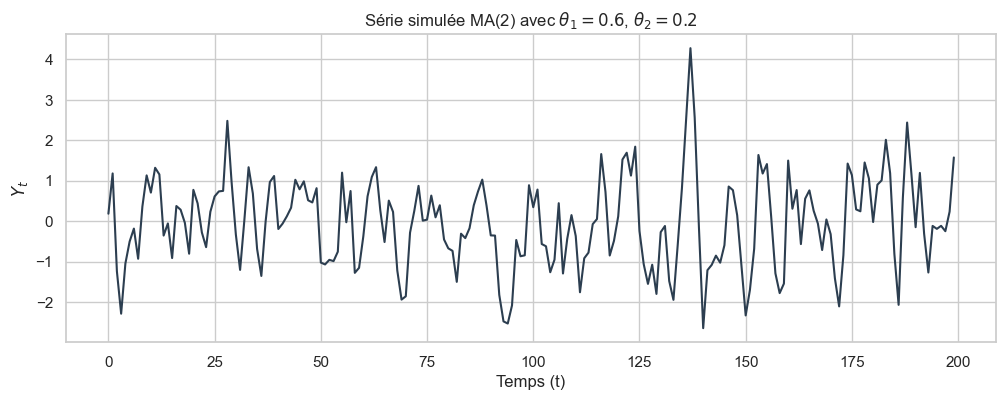

In [7]:
# Paramètres de test
theta_true = np.array([0.6, 0.2])
T = 200 # Longueur de la série temporelle

rng = np.random.default_rng(42) # Fixer la graine pour reproductibilité

# On suppose que ma_model a une fonction 'simulate'
try:
    y_sim = ma_model.simulate(theta_true, T, rng)
    
    plt.figure(figsize=(12, 4))
    plt.plot(y_sim, color='#2c3e50', linewidth=1.5)
    plt.title(f"Série simulée MA(2) avec $\\theta_1={theta_true[0]}$, $\\theta_2={theta_true[1]}$")
    plt.xlabel("Temps (t)")
    plt.ylabel("$Y_t$")
    plt.show()
except Exception as e:
    print(f"❌ Erreur lors de la simulation : {e}\nVérifiez la fonction ma_model.simulate()")

Statistiques résumées (Autocorrélations) calculées :
  rho_1 (lag 1) : 0.5522
  rho_2 (lag 2) : 0.0869


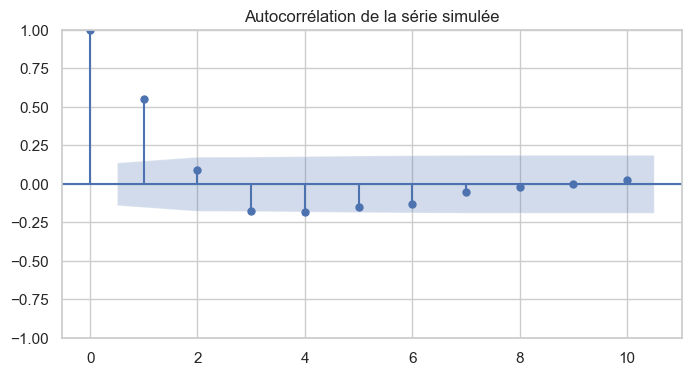

✅ Le graphique doit montrer des pics significatifs aux lags 1 et 2, puis tomber dans la zone bleue.


In [8]:
try:
    # On utilise la fonction de ton binôme !
    stats = summary_stat.summary_full(y_sim)
    print("Statistiques résumées (Autocorrélations) calculées :")
    print(f"  rho_1 (lag 1) : {stats[0]:.4f}")
    print(f"  rho_2 (lag 2) : {stats[1]:.4f}")
    
    # Vérification visuelle rapide (Correlogramme/ACF)
    import statsmodels.api as sm
    fig, ax = plt.subplots(figsize=(8, 4))
    sm.graphics.tsa.plot_acf(y_sim, lags=10, ax=ax, title="Autocorrélation de la série simulée")
    plt.show()
    
    print("✅ Le graphique doit montrer des pics significatifs aux lags 1 et 2, puis tomber dans la zone bleue.")
except Exception as e:
    print(f"❌ Erreur lors du calcul des stats : {e}")

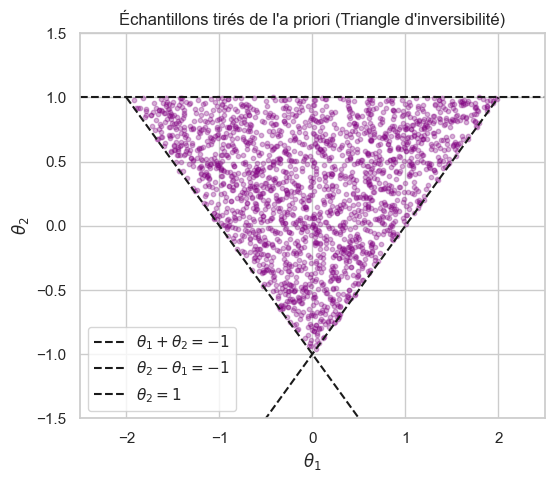

✅ Tous les points violets doivent être strictement à l'intérieur du triangle dessiné en pointillés.


In [9]:
try:
    # On demande 2000 points au prior
    prior_samples = ma_model.sample_prior(rng, n=2000)
    
    plt.figure(figsize=(6, 5))
    plt.scatter(prior_samples[:, 0], prior_samples[:, 1], alpha=0.3, s=10, color='purple')
    plt.title("Échantillons tirés de l'a priori (Triangle d'inversibilité)")
    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\theta_2$")
    
    # Dessin des bordures théoriques du triangle
    t1_vals = np.linspace(-2, 2, 100)
    plt.plot(t1_vals, -t1_vals - 1, 'k--', label="$\\theta_1 + \\theta_2 = -1$")
    plt.plot(t1_vals, t1_vals - 1, 'k--', label="$\\theta_2 - \\theta_1 = -1$")
    plt.axhline(1, color='k', linestyle='--', label="$\\theta_2 = 1$")
    
    plt.xlim(-2.5, 2.5)
    plt.ylim(-1.5, 1.5)
    plt.legend()
    plt.savefig('triangle')
    plt.show()
    
    print("✅ Tous les points violets doivent être strictement à l'intérieur du triangle dessiné en pointillés.")
except Exception as e:
    print(f"❌ Erreur lors du test du prior : {e}\nVérifiez ma_model.sample_prior()")

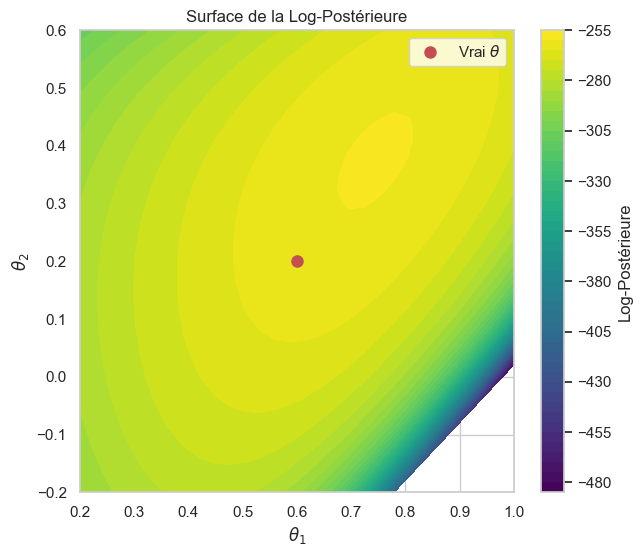

✅ Le point rouge (vrai thêta) devrait se trouver dans la zone jaune claire (vraisemblance maximale).


In [10]:
try:
    # Création d'une petite grille autour de (0.6, 0.2)
    t1_grid = np.linspace(0.2, 1.0, 30)
    t2_grid = np.linspace(-0.2, 0.6, 30)
    
    T1, T2 = np.meshgrid(t1_grid, t2_grid)
    log_lik_surface = np.zeros_like(T1)
    
    # Calcul de la vraisemblance pour chaque point de la grille
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            theta_ij = np.array([T1[i, j], T2[i, j]])
            log_lik_surface[i, j] = ma_model.log_posterior(theta_ij, y_sim, sigma=1.0)
            
    plt.figure(figsize=(7, 6))
    # On utilise un colormap (viridis) et on gère les -inf si on sort du triangle
    plt.contourf(T1, T2, log_lik_surface, levels=50, cmap="viridis")
    plt.colorbar(label="Log-Postérieure")
    plt.plot(theta_true[0], theta_true[1], 'ro', markersize=8, label="Vrai $\\theta$")
    plt.title("Surface de la Log-Postérieure")
    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\theta_2$")
    plt.legend()
    plt.show()
    
    print("✅ Le point rouge (vrai thêta) devrait se trouver dans la zone jaune claire (vraisemblance maximale).")
except Exception as e:
    print(f"❌ Erreur lors du calcul de la surface de vraisemblance : {e}\nSoit le calcul est trop lent, soit log_posterior() retourne une erreur.")